### Read a transactions database in sparse format from a txt file into a list of lists. The file contains one transaction per line, each line has a variable number of items, separated by a separator. The external list will have a list for each transaction, each transaction is a list of items. Show the first two transactions

In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'online_retail_red.txt'
random_state = 42
np.random.seed(random_state)
file=open(file_name, mode = 'r')

# The transactions are separated by a ';'
# We must also strip the '\n' at the end of the transaction
transactions = [line.strip('\n').split(";") for line in file.readlines()]

print(f"first transaction: {transactions[0]} \n second transaction: {transactions[1]}")

first transaction: ['CREAM CUPID HEARTS COAT HANGER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN'] 
 second transaction: ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK']


### Encode the list of lists into a binary representation and transform it into a dataframe whose columns are the items show the head of that dataframe


In [3]:
from mlxtend.preprocessing import TransactionEncoder
# Encode the transactions
encoder = TransactionEncoder()
encoded_transactions = encoder.fit_transform(transactions)
# Put the data in a dataframe
df = pd.DataFrame(encoded_transactions.astype(int), columns = encoder.columns_)
df.head()

,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,...,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEARTS PLANT POT HOLDER,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE SWEETHEART LETTER TRAY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Find a value of min_support such that the apriori algorithm generates at least 8 frequent itemsets with at least 2 items. Output the result with the message below

In [4]:
min_itemsets = 8
min_item_in_itemset = 2
# "Reasonable" range
support_range = np.arange(0.1, 0.01, -0.01)

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
min_support = 0
for s_value in support_range:
    print(f"Trying support value {s_value:.2f}")
    frequent_itemsets = apriori(df, min_support = s_value, use_colnames = True)
    # Calculate the number of itemsets that contain at least `min_item_in_itemset` items
    # frequent_itemsets must contains al least min_itemsets itemsset , and every item set must contains al least min_item_in_itemset item
    itemsets_above_threshold = sum([len(itemset) >= min_item_in_itemset for itemset in frequent_itemsets.itemsets])
    if itemsets_above_threshold >= min_itemsets:
        min_support = s_value
        break
if min_support == 0:
    print("No itemset found! Try again with a bigger range!")
else:
    print(f"I've selected min_support = {min_support:.2f}, which produced, {len(frequent_itemsets)} itemsets, {itemsets_above_threshold} of which had more than {min_item_in_itemset} items")

Trying support value 0.10


C:\Users\giasa\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Trying support value 0.09
Trying support value 0.08


C:\Users\giasa\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\giasa\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Trying support value 0.07


...

Trying support value 0.04


C:\Users\giasa\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Trying support value 0.03


C:\Users\giasa\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


I've selected min_support = 0.03, which produced, 148 itemsets, 12 of which had more than 2 items


In [6]:
frequent_itemsets

,support,itemsets
0,0.047835,(6 RIBBONS RUSTIC CHARM)
1,0.032505,(60 CAKE CASES VINTAGE CHRISTMAS)
2,0.042128,(60 TEATIME FAIRY CAKE CASES)
3,0.031051,(72 SWEETHEART FAIRY CAKE CASES)
4,0.049010,(ALARM CLOCK BAKELIKE GREEN)
...,...,...
143,0.039051,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)"
144,0.033960,"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROS..."
145,0.030995,"(LUNCH BAG RED RETROSPOT, LUNCH BAG PINK POLKA..."
146,0.030100,"(PAPER CHAIN KIT VINTAGE CHRISTMAS, PAPER CHAI..."


### Find the minimum metric threshold such that at least 10 association rules are extracted from the frequent itemsets found

In [17]:
metric_threshold_range = np.arange(20, 0.01, -0.01)
min_association_rule = 10
min_metric_threshold = 0
association_rule_found = 0
current_metric = "confidence"

for metric_value in metric_threshold_range:

    rules = association_rules(frequent_itemsets, metric=current_metric, min_threshold=metric_value)
    if rules.shape[0] >= min_association_rule:
        association_rule_found = rules.shape[0]
        min_metric_threshold = metric_value
        break

if association_rule_found == 0:
    print("No association rule! Try again with a bigger range!")
else:
    print(f"I've selected metric {current_metric}  with metric_value = {metric_value:.2f}, which produced , {association_rule_found} association_rules")

I've selected metric confidence  with metric_value = 0.61, which produced , 11 association_rules


### Print the first 10 rules found, sorted by descending confidence and support

In [18]:
n_rule = 10
sorted_rules=rules.sort_values(by=['confidence','support'],ascending=False).reset_index(drop=True)
sorted_rules.head(n_rule)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.039331,0.052255,0.032282,0.820768,15.707077,1.0,0.030226,5.287817,0.974669,0.544340,0.810886,0.719271
1,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.039331,0.053541,0.030547,0.776671,14.505982,1.0,0.028441,4.237964,0.969182,0.490126,0.764038,0.673602
2,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.052255,0.053541,0.039219,0.750535,14.017835,1.0,0.036421,3.793958,0.979865,0.589076,0.736423,0.741516
3,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.053541,0.052255,0.039219,0.732497,14.017835,1.0,0.036421,3.542939,0.981197,0.589076,0.717748,0.741516
4,(GARDENERS KNEELING PAD CUP OF TEA),(GARDENERS KNEELING PAD KEEP CALM),0.041960,0.050241,0.030267,0.721333,14.357586,1.0,0.028159,3.408228,0.971098,0.488708,0.706592,0.661892
5,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.064843,0.108426,0.043919,0.677308,6.246751,1.0,0.036888,2.762927,0.898156,0.339533,0.638065,0.541182
6,(PAPER CHAIN KIT VINTAGE CHRISTMAS),(PAPER CHAIN KIT 50'S CHRISTMAS),0.044758,0.062941,0.030100,0.672500,10.684680,1.0,0.027283,2.861250,0.948878,0.387888,0.650502,0.575361
7,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.049010,0.052031,0.031498,0.642694,12.352165,1.0,0.028948,2.653102,0.966406,0.452936,0.623083,0.624035
8,(JUMBO BAG BAROQUE BLACK WHITE),(JUMBO BAG RED RETROSPOT),0.050912,0.108426,0.031890,0.626374,5.776988,1.0,0.026370,2.386273,0.871257,0.250219,0.580936,0.460246
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.052255,0.039331,0.032282,0.617773,15.707077,1.0,0.030226,2.513347,0.987960,0.544340,0.602124,0.719271


### Plot confidence and support for all the sorted rules found

<Axes: title={'center': 'Association Rules'}>

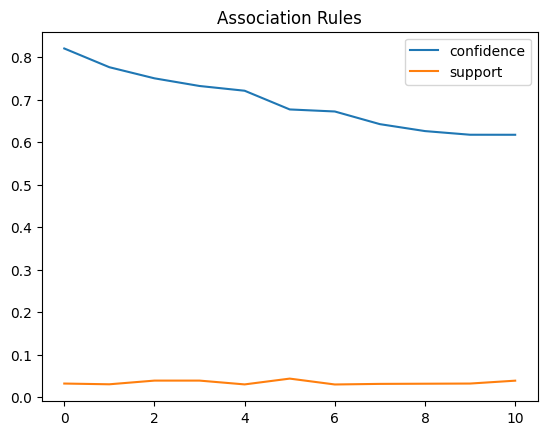

In [19]:
sorted_rules[['confidence','support']].plot(title='Association Rules')

### Scatter plot the rules by confidence and support, labelling the points with the index value of the corresponding rule

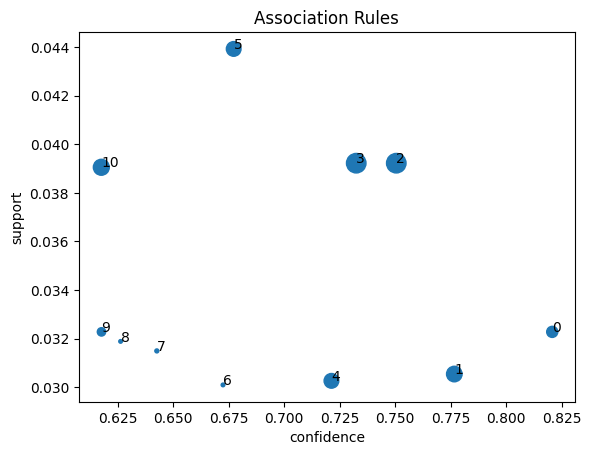

In [20]:
size_point = 1.4
# The size of each point
s = [size_point**n for n in rules.lift]

fig = sorted_rules.plot.scatter(
                                x='confidence',
                                y='support',
                                title='Association Rules',
                                s=s
                                )

# Iterate over all the rules and annotate them with their index
for i in range(len(sorted_rules)):
    fig.annotate(text = i, xy = (sorted_rules['confidence'][i], sorted_rules['support'][i]))